In [ ]:
import os
import sys
from pathlib import Path

# Dynamically locate project root and set working dir
project_root = Path().resolve().parents[1]
os.chdir(project_root)
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from catboost import CatBoostRegressor, Pool
import optuna
from typing import Union, Dict, Tuple
from sklearn.model_selection import TimeSeriesSplit
from ydata_profiling import ProfileReport
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.linear_model import LinearRegression as LR
from sklearn.ensemble import GradientBoostingRegressor as GBR
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Table of Contents
- [Dataset Preparation](#Dataset-Preparation)
- [Baseline Model](#Baseline-Model)
- [Baseline Model with target lag features](#Baseline-Model-with-Target-Lag-Features)
- [Baseline Model with all lag features](#Baseline-Model-with-All-Lag-Features)
- [Gradient Boosting with Hyperparameters Tuning](#Gradient-Boosting-with-Hyperparameters-Tuning)
- [Conclusions](#Conclusions)

# Dataset Preparation

In [2]:
%load_ext kedro.ipython

[09/25/26 11:38:02] INFO     Using                                                                  ]8;id=10271432;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=10271433;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-package                
                             s\kedro\framework\project\rich_logging.yml' as logging configuration.                 

[09/25/26 11:38:03] INFO     Registered line magic '%reload_kedro'                                   ]8;id=10271440;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271441;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=10271447;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271448;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#69\69]8;;\

                    WARNING  Kedro extension was registered but couldn't find a Kedro project. Make  ]8;id=10271454;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271455;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#72\72]8;;\
                             sure you run '%reload_kedro <project_root>'.                                          

In [3]:
%reload_kedro C:\MyDocuments\Work\GITHUB_JL\ml-project-kedro

[09/25/26 11:38:06] INFO     No typed parameter requirements found, returning original   ]8;id=10271462;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=10271463;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[09/25/26 11:38:09] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=10271470;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=10271471;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[09/25/26 11:38:10] INFO     Kedro project bikes_predict                                            ]8;id=10271477;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271478;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=10271484;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271485;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#160\160]8;;\
                             'pipelines'                                                                           

[09/25/26 11:38:13] INFO     Registered line magic 'run_viz'                                        ]8;id=10271491;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=10271492;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#166\166]8;;\

In [4]:
data = catalog.load("my_raw_data")

data.head()

                    INFO     Loading data from my_raw_data (ParquetDataset)...                 ]8;id=10271499;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10271500;file://c:\MyDocuments\Work\GITHUB_JL\ml-project-kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

,datetime,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01 00:00:00,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Let's drop the columns that are not required for further analysis and modeling.

- 'yr' does not seem to help because it
- 'casual', 'registered' are already included in the target column 'cnt'

In [5]:
drop_cols = ['yr', 'casual', 'registered', 'datetime']
data = data.drop(columns=drop_cols)
data.head(3)

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32


# Baseline Model

We will use Random Forest using Raw Features as the Baseline Model because it does not require much tuning.

Then, we will add features and try other algorithms to see how big the improvement is.

For the metrics, we will use:
- MAPE
- MAE
- RMSE

In [6]:
def compute_metrics(
    y_true: Union[np.ndarray, list], 
    y_pred: Union[np.ndarray, list]
) -> Dict[str, float]:
    """
    Compute evaluation metrics between true and predicted values.

    Metrics returned:
    - MAPE: Mean Absolute Percentage Error (in %)
    - MAE: Mean Absolute Error
    - RMSE: Root Mean Squared Error

    Parameters:
    ----------
    y_true : array-like
        Ground truth values.
    y_pred : array-like
        Predicted values.

    Returns:
    -------
    dict
        Dictionary with keys 'MAPE', 'MAE', and 'RMSE' and their float values.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 0.01, y_true))) * 100

    return {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2)
    }

In [7]:
def prepare_dataset(
    df: pd.DataFrame, 
    train_fraction: float = 0.8
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits a DataFrame into training and testing sets for features and target.

    Parameters:
    ----------
    df : pd.DataFrame
        The input DataFrame that must contain a 'target' column.
    train_fraction : float, optional (default=0.8)
        The fraction of data to use for training (between 0 and 1).

    Returns:
    -------
    x_train : pd.DataFrame
        Training features.
    x_test : pd.DataFrame
        Testing features.
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Testing target values.
    """
    feats = [col for col in df.columns if col != 'target']
    x, y = df[feats], df['target']
    train_size = int(train_fraction * df.shape[0])
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    return x_train, x_test, y_train, y_test

#### Target definition

For the target, we will use the next hour bike count because we want to predict what this value will be ti adjust the pricing.

In [ ]:
# Prepare the data for training
df = data.copy() # copy the original data to avoid modifying it directly

# Create the target variable by shifting the 'cnt' column to predict the next time step
df['target'] = df['cnt'].shift(-1).fillna(method='ffill')
df.drop(columns=['cnt'], inplace=True)

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [11]:
%%time
model = RF(n_estimators=100)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

CPU times: total: 3.22 s
Wall time: 3.28 s


In [12]:
metrics_base = compute_metrics(y_test.values, y_pred)
metrics_base

{'MAE': 85.46, 'RMSE': 123.63, 'MAPE': 39.04}

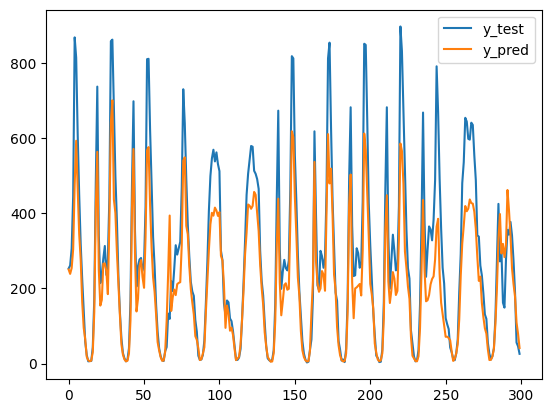

In [13]:
n = 300
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend()